Customer Segmentation with Targeting Marketing Strategy

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import LabelEncoder, StandardScaler
import warnings
warnings.filterwarnings("ignore")

Load Dataset

In [33]:
df = pd.read_csv("Mall_Customers.csv")
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


Basic EDA

In [34]:
print(df.info())
print(df.describe())
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB
None
       CustomerID         Age  Annual Income (k$)  Spending Score (1-100)
count  200.000000  200.000000          200.000000              200.000000
mean   100.500000   38.850000           60.560000               50.200000
std     57.879185   13.969007           26.264721               25.823522
min      1.000000   18.000000           15.000000                1.000000
25%     50.750000   28.750000           41.500000               34.750000
50%    100.500000   36.000000    

Data Preprocessing

In [35]:
# Rename columns for easier access
df.rename(columns={"Gender": "Gender", "Age": "Age", "Annual Income (k$)": "AnnualIncome", "Spending Score (1-100)": "SpendingScore"}, inplace=True)

# Encode Gender
le = LabelEncoder()
df["GenderEncoded"] = le.fit_transform(df["Gender"])  # Male=1, Female=0

# Drop unneeded columns
df.drop(["CustomerID", "Gender"], axis=1, inplace=True)

Standardize Features

In [36]:
scaler = StandardScaler()
scaled_features = scaler.fit_transform(df)

Find Optimal K (Elbow Method)

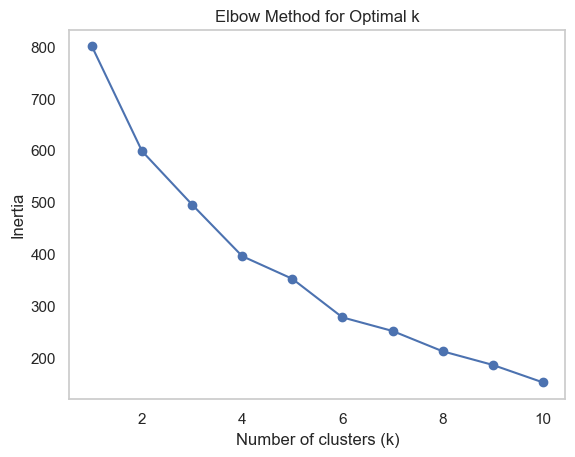

In [37]:
inertia = []
K_range = range(1, 11)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(scaled_features)
    inertia.append(km.inertia_)

plt.plot(K_range, inertia, 'bo-')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal k')
plt.grid()
plt.show()

KMeans Clustering (Assume k=5 based on elbow curve)

In [38]:
kmeans = KMeans(n_clusters=5, random_state=42)
df["Cluster"] = kmeans.fit_predict(scaled_features)

Add cluster labels to the original dataframe

In [39]:
df['Cluster'] = kmeans.labels_
numeric_columns = df.select_dtypes(include='number').columns


Cluster Summary

In [40]:
cluster_summary = df.groupby("Cluster")[numeric_columns].mean()
print("Cluster-wise Summary (Numeric Features):\n")
display(cluster_summary)

Cluster-wise Summary (Numeric Features):



,Age,AnnualIncome,SpendingScore,GenderEncoded,Cluster
Cluster,,,,,
0,56.470588,46.098039,39.313725,0.509804,0.0
1,39.500000,85.150000,14.050000,1.000000,1.0
2,28.690476,60.904762,70.238095,1.000000,2.0
3,37.897959,82.122449,54.448980,0.000000,3.0
4,27.315789,38.842105,56.210526,0.000000,4.0


Visualize Clusters

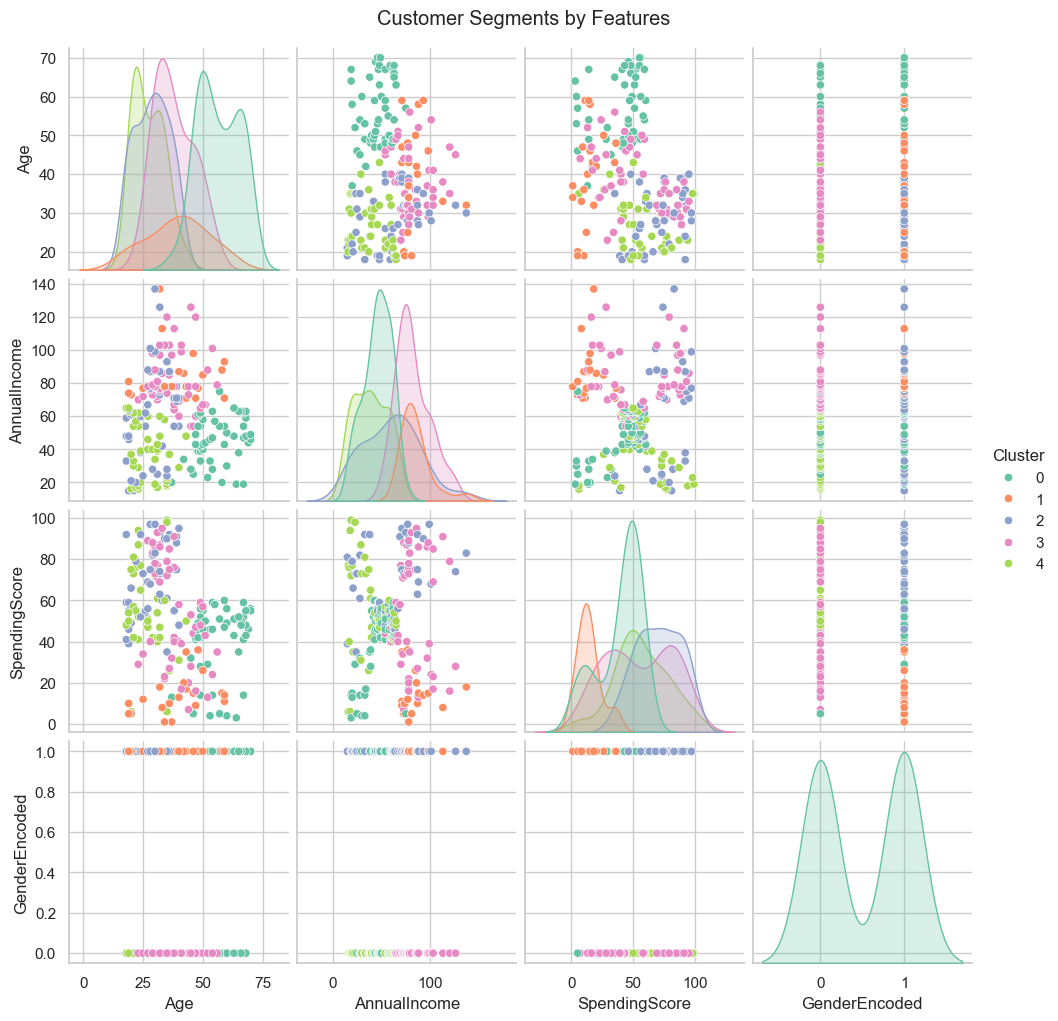

In [41]:
sns.pairplot(df, hue='Cluster', palette='Set2', diag_kind='kde')
plt.suptitle("Customer Segments by Features", y=1.02)
plt.show()

In [44]:
print(df.columns)

Index(['Age', 'AnnualIncome', 'SpendingScore', 'GenderEncoded', 'Cluster'], dtype='object')


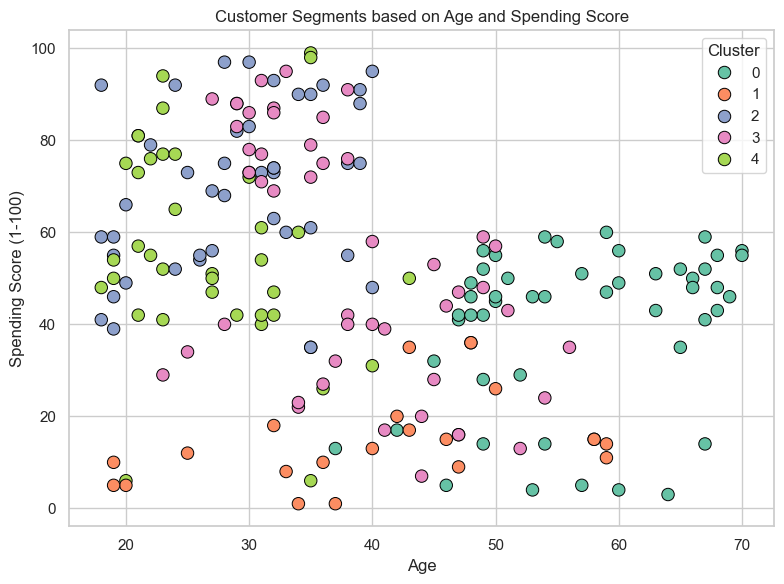

In [45]:
sns.set(style="whitegrid")

plt.figure(figsize=(8, 6))
sns.scatterplot(
    x='Age',
    y='SpendingScore',
    hue='Cluster',
    palette='Set2',
    data=df,
    s=80,
    edgecolor='black'
)
plt.title('Customer Segments based on Age and Spending Score')
plt.xlabel('Age')
plt.ylabel('Spending Score (1-100)')
plt.legend(title='Cluster')
plt.tight_layout()
plt.show()

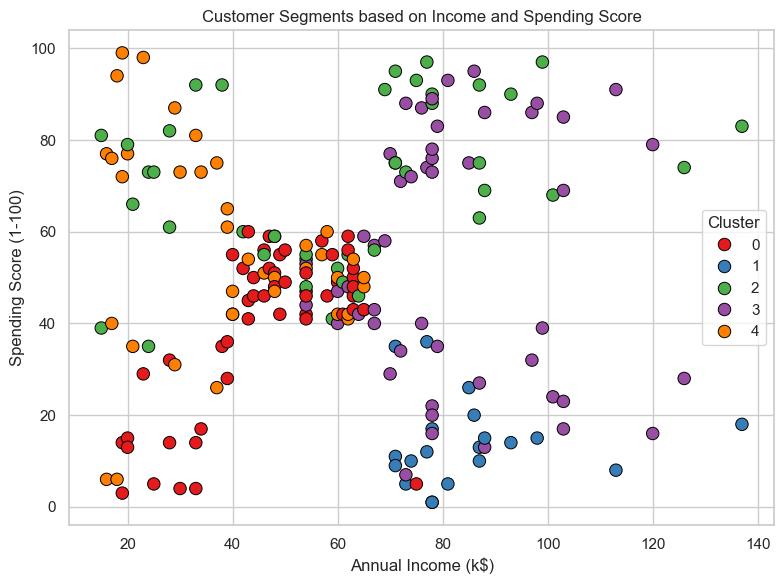

In [46]:
plt.figure(figsize=(8, 6))
sns.scatterplot(
    x='AnnualIncome',
    y='SpendingScore',
    hue='Cluster',
    palette='Set1',
    data=df,
    s=80,
    edgecolor='black'
)
plt.title('Customer Segments based on Income and Spending Score')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.legend(title='Cluster')
plt.tight_layout()
plt.show()

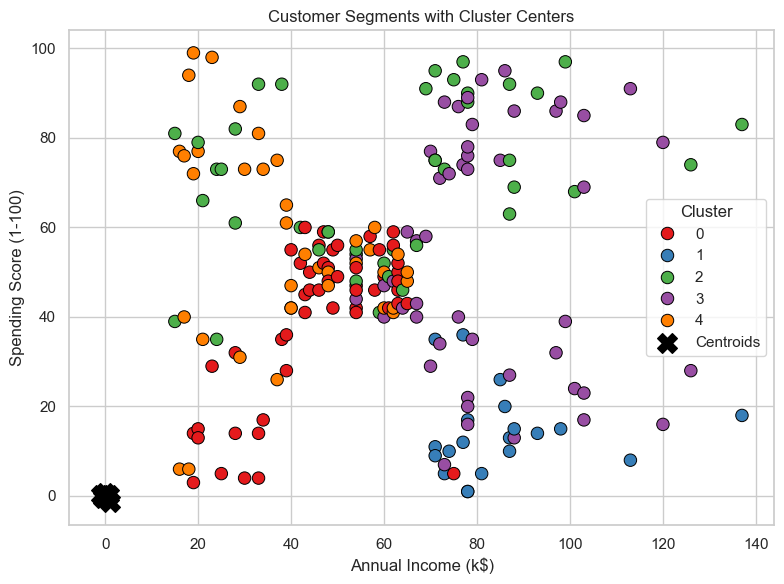

In [47]:
centers = kmeans.cluster_centers_

# Plot with cluster centers on second plot
plt.figure(figsize=(8, 6))
sns.scatterplot(
    x='AnnualIncome',
    y='SpendingScore',
    hue='Cluster',
    palette='Set1',
    data=df,
    s=80,
    edgecolor='black'
)
plt.scatter(
    centers[:, 1],  # Annual Income (index 1)
    centers[:, 2],  # Spending Score (index 2)
    s=200,
    c='black',
    label='Centroids',
    marker='X'
)
plt.title('Customer Segments with Cluster Centers')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.legend(title='Cluster')
plt.tight_layout()
plt.show()

Add Marketing Strategy Based on cluster Features

In [52]:
def marketing_strategy(row):
    if row['AnnualIncome'] > 80 and row['SpendingScore'] < 40:
        return 'Premium Ads + Personalized Offers'
    elif row['Age'] < 30 and row['SpendingScore'] > 70:
        return 'Flash Sales + Influencer Campaigns'
    elif row['AnnualIncome'] < 40:
        return 'Budget Deals + Referral Rewards'
    else:
        return 'General Engagement Campaigns'

df["MarketingStrategy"] = df.apply(marketing_strategy, axis=1)

Add Cluster Profiles (for Marketing Insight)

In [53]:
for cluster_id in sorted(df['Cluster'].unique()):
    cluster_data = df[df['Cluster'] == cluster_id]
    print(f"\n📂 Cluster {cluster_id}:")
    print(f"Customers: {len(cluster_data)}")
    print(f"Average Age: {cluster_data['Age'].mean():.2f}")
    print(f"Average Income: {cluster_data['AnnualIncome'].mean():.2f}")
    print(f"Average Spending Score: {cluster_data['SpendingScore'].mean():.2f}")


📂 Cluster 0:
Customers: 51
Average Age: 56.47
Average Income: 46.10
Average Spending Score: 39.31

📂 Cluster 1:
Customers: 20
Average Age: 39.50
Average Income: 85.15
Average Spending Score: 14.05

📂 Cluster 2:
Customers: 42
Average Age: 28.69
Average Income: 60.90
Average Spending Score: 70.24

📂 Cluster 3:
Customers: 49
Average Age: 37.90
Average Income: 82.12
Average Spending Score: 54.45

📂 Cluster 4:
Customers: 38
Average Age: 27.32
Average Income: 38.84
Average Spending Score: 56.21


Export Final Segmented Customer Data

In [54]:
df.to_csv("Segmented_Customers_with_Strategies.csv", index=False)
df.head()

,Age,AnnualIncome,SpendingScore,GenderEncoded,Cluster,MarketingStrategy
0,19,15,39,1,2,Budget Deals + Referral Rewards
1,21,15,81,1,2,Flash Sales + Influencer Campaigns
2,20,16,6,0,4,Budget Deals + Referral Rewards
3,23,16,77,0,4,Flash Sales + Influencer Campaigns
4,31,17,40,0,4,Budget Deals + Referral Rewards
